In [ ]:
#pip install ipykernel -U --user --force-reinstall
import pandas as pd

: 

In [141]:
import os
print(os.getcwd())

data_dir = '/Users/pakeunseo/Desktop/2024-하/multicampus/pandas/data/'
file_name = 'gapminder.tsv'
data_path = os.path.join(data_dir, file_name)

/Users/pakeunseo/Desktop/2024-하/multicampus/practice


# 1. 데이터 읽기

In [109]:
df = pd.read_csv(data_path, sep='\t')
type(df)

pandas.core.frame.DataFrame

## 1.1 데이터 프레임 이해하기

In [110]:
# (row, column)
df.shape

(1704, 6)

In [111]:
# view 5 contents
df.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


In [112]:
#view only columns
df.columns

Index(['country', 'continent', 'year', 'lifeExp', 'pop', 'gdpPercap'], dtype='object')

In [113]:
df.dtypes

country       object
continent     object
year           int64
lifeExp      float64
pop            int64
gdpPercap    float64
dtype: object

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 80.0+ KB


## 1.2 데이터 추출하기

### 1.2.1 열 추출

In [115]:
df1 = df['country']
df1.head()

0    Afghanistan
1    Afghanistan
2    Afghanistan
3    Afghanistan
4    Afghanistan
Name: country, dtype: object

In [116]:
# []로 출력을 하면 series 형태로 반환되기 때문에 에러가 뜬다. 
# df['country','continent']
# 따라서 dataframe 형태로 출력을 해야 한다. 
df[['country','continent']]

,country,continent
0,Afghanistan,Asia
1,Afghanistan,Asia
2,Afghanistan,Asia
3,Afghanistan,Asia
4,Afghanistan,Asia
...,...,...
1699,Zimbabwe,Africa
1700,Zimbabwe,Africa
1701,Zimbabwe,Africa
1702,Zimbabwe,Africa


In [117]:
df2 = df[['country','continent','year','gdpPercap']]
df2

,country,continent,year,gdpPercap
0,Afghanistan,Asia,1952,779.445314
1,Afghanistan,Asia,1957,820.853030
2,Afghanistan,Asia,1962,853.100710
3,Afghanistan,Asia,1967,836.197138
4,Afghanistan,Asia,1972,739.981106
...,...,...,...,...
1699,Zimbabwe,Africa,1987,706.157306
1700,Zimbabwe,Africa,1992,693.420786
1701,Zimbabwe,Africa,1997,792.449960
1702,Zimbabwe,Africa,2002,672.038623


In [118]:
type(df1), type(df2)

(pandas.core.series.Series, pandas.core.frame.DataFrame)

### 1.2.2 행 추출

1. loc(행 이름)
2. iloc(행 번호)

In [119]:
df.loc[:10]

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106
5,Afghanistan,Asia,1977,38.438,14880372,786.113360
6,Afghanistan,Asia,1982,39.854,12881816,978.011439
7,Afghanistan,Asia,1987,40.822,13867957,852.395945
8,Afghanistan,Asia,1992,41.674,16317921,649.341395
9,Afghanistan,Asia,1997,41.763,22227415,635.341351


In [120]:
df.loc[[100]]

,country,continent,year,lifeExp,pop,gdpPercap
100,Bangladesh,Asia,1972,45.252,70759295,630.233627


In [121]:
df.loc[[df.shape[0]-1]]

,country,continent,year,lifeExp,pop,gdpPercap
1703,Zimbabwe,Africa,2007,43.487,12311143,469.709298


In [122]:
df.tail(1)

,country,continent,year,lifeExp,pop,gdpPercap
1703,Zimbabwe,Africa,2007,43.487,12311143,469.709298


In [123]:
# 여러 행 추출
df.loc[[1,3,4]]

,country,continent,year,lifeExp,pop,gdpPercap
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


In [124]:
df.loc[1:10,['country']]

,country
1,Afghanistan
2,Afghanistan
3,Afghanistan
4,Afghanistan
5,Afghanistan
6,Afghanistan
7,Afghanistan
8,Afghanistan
9,Afghanistan
10,Afghanistan


In [125]:
df.iloc[1:10,[0]]

,country
1,Afghanistan
2,Afghanistan
3,Afghanistan
4,Afghanistan
5,Afghanistan
6,Afghanistan
7,Afghanistan
8,Afghanistan
9,Afghanistan


In [126]:
df.iloc[:,list(range(1,5))]

,continent,year,lifeExp,pop
0,Asia,1952,28.801,8425333
1,Asia,1957,30.332,9240934
2,Asia,1962,31.997,10267083
3,Asia,1967,34.020,11537966
4,Asia,1972,36.088,13079460
...,...,...,...,...
1699,Africa,1987,62.351,9216418
1700,Africa,1992,60.377,10704340
1701,Africa,1997,46.809,11404948
1702,Africa,2002,39.989,11926563


In [127]:
df.iloc[:10,[-1]]

,gdpPercap
0,779.445314
1,820.853030
2,853.100710
3,836.197138
4,739.981106
5,786.113360
6,978.011439
7,852.395945
8,649.341395
9,635.341351


## 1.3 기초 통계 계산하기

In [128]:
df.describe()

,year,lifeExp,pop,gdpPercap
count,1704.00000,1704.000000,1.704000e+03,1704.000000
mean,1979.50000,59.474439,2.960121e+07,7215.327081
std,17.26533,12.917107,1.061579e+08,9857.454543
min,1952.00000,23.599000,6.001100e+04,241.165876
25%,1965.75000,48.198000,2.793664e+06,1202.060309
50%,1979.50000,60.712500,7.023596e+06,3531.846988
75%,1993.25000,70.845500,1.958522e+07,9325.462346
max,2007.00000,82.603000,1.318683e+09,113523.132900


In [129]:
#gruopby 
#year로 groupby해서 lifeexp의 평균값을 본다. 
df.groupby('year')['lifeExp'].mean()

year
1952    49.057620
1957    51.507401
1962    53.609249
1967    55.678290
1972    57.647386
1977    59.570157
1982    61.533197
1987    63.212613
1992    64.160338
1997    65.014676
2002    65.694923
2007    67.007423
Name: lifeExp, dtype: float64

In [130]:
#대륙별 인구 수 최대값
df.groupby('continent')['pop'].max().sort_index(ascending=False)

continent
Oceania       20434176
Europe        82400996
Asia        1318683096
Americas     301139947
Africa       135031164
Name: pop, dtype: int64

In [131]:
#최대값 기준으로 정렬하기 

df.groupby('continent')['pop'].max().sort_values(ascending=False)

continent
Asia        1318683096
Americas     301139947
Africa       135031164
Europe        82400996
Oceania       20434176
Name: pop, dtype: int64

In [135]:
# 빈도수 계산 
#nunique() 중복 제외

df.groupby('continent')['country'].nunique()

continent
Africa      52
Americas    25
Asia        33
Europe      30
Oceania      2
Name: country, dtype: int64

In [136]:
#value_counts() 중복 포함 

df.groupby('continent')['country'].value_counts()

continent  country       
Africa     Algeria           12
           Angola            12
           Benin             12
           Botswana          12
           Burkina Faso      12
                             ..
Europe     Switzerland       12
           Turkey            12
           United Kingdom    12
Oceania    Australia         12
           New Zealand       12
Name: country, Length: 142, dtype: int64

## 1.4 그래프로 그리기

<AxesSubplot:xlabel='year'>

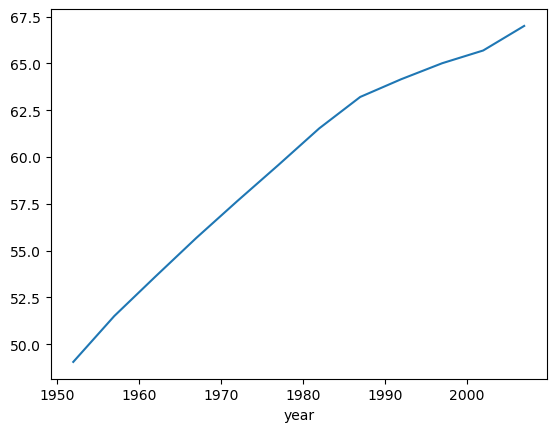

In [139]:
year_lifeExp_mean = df.groupby('year')['lifeExp'].mean()
year_lifeExp_mean.plot()

# 2. 데이터 다루기

## 2.1 시리즈 만들기

## 2.2 Dataframe 만들기

In [164]:
scientists = pd.DataFrame(
    data = {
        "Occupation": ["Chemist", "Statistician"],
        "Born": ["1920-07-25", "1876-06-13"],
        "Died": ["1958-04-16", "1937-10-16"],
        "Age": [37, 61],
}
    ,
    index = ['Rosaline Franklin','William Gosset']
)

In [165]:
scientists.columns

Index(['Occupation', 'Born', 'Died', 'Age'], dtype='object')

In [166]:
scientists

,Occupation,Born,Died,Age
Rosaline Franklin,Chemist,1920-07-25,1958-04-16,37
William Gosset,Statistician,1876-06-13,1937-10-16,61


In [172]:
f_row= scientists.loc['Rosaline Franklin']
print(f_row)
print(f_row.values)
print(f_row.index)

Occupation       Chemist
Born          1920-07-25
Died          1958-04-16
Age                   37
Name: Rosaline Franklin, dtype: object
['Chemist' '1920-07-25' '1958-04-16' 37]
Index(['Occupation', 'Born', 'Died', 'Age'], dtype='object')


In [173]:
f_row.keys()

Index(['Occupation', 'Born', 'Died', 'Age'], dtype='object')

In [185]:
scientists['Age']

Rosaline Franklin    37
William Gosset       61
Name: Age, dtype: int64

In [184]:
scientists.loc[:,'Age']

Rosaline Franklin    37
William Gosset       61
Name: Age, dtype: int64

In [190]:
age = scientists['Age']
print(age.mean())
print(age.min())
print(age.max())
print(age.std())


49.0
37
61
16.97056274847714


In [197]:
file_name2 = 'scientists.csv'
data_path2 = os.path.join(data_dir, file_name2)
scient2 = pd.read_csv(data_path2, sep=',')

In [198]:
scient2

,Name,Born,Died,Age,Occupation
0,Rosaline Franklin,1920-07-25,1958-04-16,37,Chemist
1,William Gosset,1876-06-13,1937-10-16,61,Statistician
2,Florence Nightingale,1820-05-12,1910-08-13,90,Nurse
3,Marie Curie,1867-11-07,1934-07-04,66,Chemist
4,Rachel Carson,1907-05-27,1964-04-14,56,Biologist
5,John Snow,1813-03-15,1858-06-16,45,Physician
6,Alan Turing,1912-06-23,1954-06-07,41,Computer Scientist
7,Johann Gauss,1777-04-30,1855-02-23,77,Mathematician


In [199]:
scient2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Name        8 non-null      object
 1   Born        8 non-null      object
 2   Died        8 non-null      object
 3   Age         8 non-null      int64 
 4   Occupation  8 non-null      object
dtypes: int64(1), object(4)
memory usage: 448.0+ bytes


In [208]:
ages=scient2['Age']

In [209]:
scient2['Age'].describe()

count     8.000000
mean     59.125000
std      18.325918
min      37.000000
25%      44.000000
50%      58.500000
75%      68.750000
max      90.000000
Name: Age, dtype: float64

In [210]:
ages[ages>ages.mean()]

1    61
2    90
3    66
7    77
Name: Age, dtype: int64

In [211]:
s1 = pd.Series([1,100])
s1

0      1
1    100
dtype: int64

In [212]:
ages + s1

0     38.0
1    161.0
2      NaN
3      NaN
4      NaN
5      NaN
6      NaN
7      NaN
dtype: float64

In [213]:
ages.sort_index(ascending=False)

7    77
6    41
5    45
4    56
3    66
2    90
1    61
0    37
Name: Age, dtype: int64

In [223]:
first_half = scient2[:4]
second_half = scient2[4:]


In [224]:
scient2*2

,Name,Born,Died,Age,Occupation
0,Rosaline FranklinRosaline Franklin,1920-07-251920-07-25,1958-04-161958-04-16,74,ChemistChemist
1,William GossetWilliam Gosset,1876-06-131876-06-13,1937-10-161937-10-16,122,StatisticianStatistician
2,Florence NightingaleFlorence Nightingale,1820-05-121820-05-12,1910-08-131910-08-13,180,NurseNurse
3,Marie CurieMarie Curie,1867-11-071867-11-07,1934-07-041934-07-04,132,ChemistChemist
4,Rachel CarsonRachel Carson,1907-05-271907-05-27,1964-04-141964-04-14,112,BiologistBiologist
5,John SnowJohn Snow,1813-03-151813-03-15,1858-06-161858-06-16,90,PhysicianPhysician
6,Alan TuringAlan Turing,1912-06-231912-06-23,1954-06-071954-06-07,82,Computer ScientistComputer Scientist
7,Johann GaussJohann Gauss,1777-04-301777-04-30,1855-02-231855-02-23,154,MathematicianMathematician


In [230]:
df1 = df2 = pd.DataFrame(
    data = [[1,2,3],[4,5,6]]
)
df1.add(df2)

,0,1,2
0,2,4,6
1,8,10,12


,0
0,246
1,912


## 2.4 열추가

In [231]:
scient2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Name        8 non-null      object
 1   Born        8 non-null      object
 2   Died        8 non-null      object
 3   Age         8 non-null      int64 
 4   Occupation  8 non-null      object
dtypes: int64(1), object(4)
memory usage: 448.0+ bytes


In [245]:
# str -> datetime

scient2['Born']= pd.to_datetime(scient2['Born'],format='%Y-%m-%d')

In [246]:
scient2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Name        8 non-null      object        
 1   Born        8 non-null      datetime64[ns]
 2   Died        8 non-null      object        
 3   Age         8 non-null      int64         
 4   Occupation  8 non-null      object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 448.0+ bytes


0   1920-07-25
1   1876-06-13
2   1820-05-12
3   1867-11-07
4   1907-05-27
5   1813-03-15
6   1912-06-23
7   1777-04-30
Name: Born, dtype: datetime64[ns]

## 2.5 열 삭제

In [263]:
scient3_d=scient2.drop(['Age'], axis = 1) #(1, column)
scient3_d 

,Name,Born,Died,Occupation
0,Rosaline Franklin,1920-07-25,1958-04-16,Chemist
1,William Gosset,1876-06-13,1937-10-16,Statistician
2,Florence Nightingale,1820-05-12,1910-08-13,Nurse
3,Marie Curie,1867-11-07,1934-07-04,Chemist
4,Rachel Carson,1907-05-27,1964-04-14,Biologist
5,John Snow,1813-03-15,1858-06-16,Physician
6,Alan Turing,1912-06-23,1954-06-07,Computer Scientist
7,Johann Gauss,1777-04-30,1855-02-23,Mathematician


## 2.6 파일 저장

#save pickle
scient2['Name'].to_pickle('/Users/pakeunseo/Desktop/2024-하/multicampus/pandas/data/scientist_name_series.pickle')

In [267]:
#read pickle
series_pk1= pd.read_pickle('/Users/pakeunseo/Desktop/2024-하/multicampus/pandas/data/scientist_name_series.pickle')

0       Rosaline Franklin
1          William Gosset
2    Florence Nightingale
3             Marie Curie
4           Rachel Carson
5               John Snow
6             Alan Turing
7            Johann Gauss
Name: Name, dtype: object

# 3-1. 깔끔한 데이터

In [279]:
data_dir3 = '/Users/pakeunseo/Desktop/2024-하/multicampus/pandas/data/'
file_name3 = 'pew.csv'
data_path3 = os.path.join(data_dir3, file_name3)
pew = pd.read_csv(data_path3)
pew

,religion,<$10k,$10-20k,$20-30k,$30-40k,$40-50k,$50-75k,$75-100k,$100-150k,>150k,Don't know/refused
0,Agnostic,27,34,60,81,76,137,122,109,84,96
1,Atheist,12,27,37,52,35,70,73,59,74,76
2,Buddhist,27,21,30,34,33,58,62,39,53,54
3,Catholic,418,617,732,670,638,1116,949,792,633,1489
4,Don’t know/refused,15,14,15,11,10,35,21,17,18,116
5,Evangelical Prot,575,869,1064,982,881,1486,949,723,414,1529
6,Hindu,1,9,7,9,11,34,47,48,54,37
7,Historically Black Prot,228,244,236,238,197,223,131,81,78,339
8,Jehovah's Witness,20,27,24,24,21,30,15,11,6,37
9,Jewish,19,19,25,25,30,95,69,87,151,162


In [289]:
#하나의 컬럼으로 합치기 : '언피봇' , '피본되돌리기' : melt

pew_long=pew.melt(id_vars='religion',var_name='income',value_name='count')
pew_long

,religion,income,count
0,Agnostic,<$10k,27
1,Atheist,<$10k,12
2,Buddhist,<$10k,27
3,Catholic,<$10k,418
4,Don’t know/refused,<$10k,15
...,...,...,...
175,Orthodox,Don't know/refused,73
176,Other Christian,Don't know/refused,18
177,Other Faiths,Don't know/refused,71
178,Other World Religions,Don't know/refused,8


In [292]:
evola = pd.read_csv('/Users/pakeunseo/Desktop/2024-하/multicampus/pandas/data/country_timeseries.csv')

In [293]:
evola.columns

Index(['Date', 'Day', 'Cases_Guinea', 'Cases_Liberia', 'Cases_SierraLeone',
       'Cases_Nigeria', 'Cases_Senegal', 'Cases_UnitedStates', 'Cases_Spain',
       'Cases_Mali', 'Deaths_Guinea', 'Deaths_Liberia', 'Deaths_SierraLeone',
       'Deaths_Nigeria', 'Deaths_Senegal', 'Deaths_UnitedStates',
       'Deaths_Spain', 'Deaths_Mali'],
      dtype='object')

In [298]:
evola.head()

,Date,Day,Cases_Guinea,Cases_Liberia,Cases_SierraLeone,Cases_Nigeria,Cases_Senegal,Cases_UnitedStates,Cases_Spain,Cases_Mali,Deaths_Guinea,Deaths_Liberia,Deaths_SierraLeone,Deaths_Nigeria,Deaths_Senegal,Deaths_UnitedStates,Deaths_Spain,Deaths_Mali
0,1/5/2015,289,2776.0,NaN,10030.0,NaN,NaN,NaN,NaN,NaN,1786.0,NaN,2977.0,NaN,NaN,NaN,NaN,NaN
1,1/4/2015,288,2775.0,NaN,9780.0,NaN,NaN,NaN,NaN,NaN,1781.0,NaN,2943.0,NaN,NaN,NaN,NaN,NaN
2,1/3/2015,287,2769.0,8166.0,9722.0,NaN,NaN,NaN,NaN,NaN,1767.0,3496.0,2915.0,NaN,NaN,NaN,NaN,NaN
3,1/2/2015,286,NaN,8157.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3496.0,NaN,NaN,NaN,NaN,NaN,NaN
4,12/31/2014,284,2730.0,8115.0,9633.0,NaN,NaN,NaN,NaN,NaN,1739.0,3471.0,2827.0,NaN,NaN,NaN,NaN,NaN


In [295]:
evola_long = evola.melt(id_vars=['Date','Day'])
evola_long

,Date,Day,variable,value
0,1/5/2015,289,Cases_Guinea,2776.0
1,1/4/2015,288,Cases_Guinea,2775.0
2,1/3/2015,287,Cases_Guinea,2769.0
3,1/2/2015,286,Cases_Guinea,NaN
4,12/31/2014,284,Cases_Guinea,2730.0
...,...,...,...,...
1947,3/27/2014,5,Deaths_Mali,NaN
1948,3/26/2014,4,Deaths_Mali,NaN
1949,3/25/2014,3,Deaths_Mali,NaN
1950,3/24/2014,2,Deaths_Mali,NaN


In [302]:
var_split = evola_long.variable.str.split('_')
var_split

0       [Cases, Guinea]
1       [Cases, Guinea]
2       [Cases, Guinea]
3       [Cases, Guinea]
4       [Cases, Guinea]
             ...       
1947     [Deaths, Mali]
1948     [Deaths, Mali]
1949     [Deaths, Mali]
1950     [Deaths, Mali]
1951     [Deaths, Mali]
Name: variable, Length: 1952, dtype: object

In [304]:
status_values = var_split.str.get(0)
country_values = var_split.str.get(1)

In [305]:
status_values

0        Cases
1        Cases
2        Cases
3        Cases
4        Cases
         ...  
1947    Deaths
1948    Deaths
1949    Deaths
1950    Deaths
1951    Deaths
Name: variable, Length: 1952, dtype: object

In [306]:
country_values

0       Guinea
1       Guinea
2       Guinea
3       Guinea
4       Guinea
         ...  
1947      Mali
1948      Mali
1949      Mali
1950      Mali
1951      Mali
Name: variable, Length: 1952, dtype: object

In [308]:
evola_long['status'] = status_values
evola_long['country'] = country_values

In [309]:
evola_long

,Date,Day,variable,value,status,country
0,1/5/2015,289,Cases_Guinea,2776.0,Cases,Guinea
1,1/4/2015,288,Cases_Guinea,2775.0,Cases,Guinea
2,1/3/2015,287,Cases_Guinea,2769.0,Cases,Guinea
3,1/2/2015,286,Cases_Guinea,NaN,Cases,Guinea
4,12/31/2014,284,Cases_Guinea,2730.0,Cases,Guinea
...,...,...,...,...,...,...
1947,3/27/2014,5,Deaths_Mali,NaN,Deaths,Mali
1948,3/26/2014,4,Deaths_Mali,NaN,Deaths,Mali
1949,3/25/2014,3,Deaths_Mali,NaN,Deaths,Mali
1950,3/24/2014,2,Deaths_Mali,NaN,Deaths,Mali


In [311]:
 evola_long1 = evola.melt(id_vars=['Date','Day'])

In [315]:
#expand가 자체적으로 df를 생성함 
var_split1 = evola_long1.variable.str.split('_',expand=True) 

In [316]:
evola_long1[['status','country']] = var_split1
evola_long1

,Date,Day,variable,value,status,country
0,1/5/2015,289,Cases_Guinea,2776.0,Cases,Guinea
1,1/4/2015,288,Cases_Guinea,2775.0,Cases,Guinea
2,1/3/2015,287,Cases_Guinea,2769.0,Cases,Guinea
3,1/2/2015,286,Cases_Guinea,NaN,Cases,Guinea
4,12/31/2014,284,Cases_Guinea,2730.0,Cases,Guinea
...,...,...,...,...,...,...
1947,3/27/2014,5,Deaths_Mali,NaN,Deaths,Mali
1948,3/26/2014,4,Deaths_Mali,NaN,Deaths,Mali
1949,3/25/2014,3,Deaths_Mali,NaN,Deaths,Mali
1950,3/24/2014,2,Deaths_Mali,NaN,Deaths,Mali
